In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [12]:
# ResNet50

In [3]:
# ==========================
# SILENT SETUP & IMPORTS
# ==========================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_CPP_MAX_VLOG_LEVEL'] = '0'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

In [4]:
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [5]:
# ==========================
# CONFIG
# ==========================
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
TRAIN_DIR = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train"
TEST_DIR = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final"

In [6]:
# ==========================
# DATA LOADING
# ==========================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='binary'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='binary'
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

Found 4733 files belonging to 2 classes.
Using 3787 files for training.


I0000 00:00:1776579904.919875      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776579904.925853      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4733 files belonging to 2 classes.
Using 946 files for validation.


In [7]:
# ==========================
# MODEL SETUP (ResNet50)
# ==========================
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

# Loading ResNet50 instead of MobileNet
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False 

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)

# ResNet50 has its own specific preprocessing (scaling is different than MobileNet!)
x = tf.keras.applications.resnet50.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# ==========================
# PHASE 1: TRAINING HEAD
# ==========================
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]

print("\n--- Training ResNet50 Head ---")
history = model.fit(train_ds, validation_data=val_ds, epochs=10, callbacks=callbacks)


--- Training ResNet50 Head ---
Epoch 1/10


I0000 00:00:1776579935.375975     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


119/119 ━━━━━━━━━━━━━━━━━━━━ 42s 178ms/step - accuracy: 0.9463 - loss: 0.1369 - val_accuracy: 0.9937 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 146ms/step - accuracy: 0.9876 - loss: 0.0466 - val_accuracy: 0.9937 - val_loss: 0.0209 - learning_rate: 0.0010
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 17s 147ms/step - accuracy: 0.9931 - loss: 0.0197 - val_accuracy: 0.9947 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.9927 - loss: 0.0196 - val_accuracy: 0.9979 - val_loss: 0.0077 - learning_rate: 2.0000e-04
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.9958 - loss: 0.0069 - val_accuracy: 0.9958 - val_loss: 0.0074 - learning_rate: 2.0000e-04
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 150ms/step - accuracy: 0.9992 - loss: 0.0047 - val_accuracy: 0.9958 - val_loss: 0.0085 - learning_rate: 2.0000e-04
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.

In [9]:
# ==========================
# PHASE 2: FINE-TUNING
# ==========================
base_model.trainable = True
# Unfreeze the last 30 layers for ResNet
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

print("\n--- Fine-tuning ResNet50 ---")
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=5, callbacks=callbacks)


--- Fine-tuning ResNet50 ---
Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 38s 225ms/step - accuracy: 0.9937 - loss: 0.0175 - val_accuracy: 0.9958 - val_loss: 0.0133 - learning_rate: 1.0000e-05
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 202ms/step - accuracy: 0.9945 - loss: 0.0118 - val_accuracy: 0.9947 - val_loss: 0.0093 - learning_rate: 1.0000e-05
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 203ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.9947 - val_loss: 0.0089 - learning_rate: 1.0000e-05
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 203ms/step - accuracy: 0.9983 - loss: 0.0036 - val_accuracy: 0.9947 - val_loss: 0.0102 - learning_rate: 1.0000e-05
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 203ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9947 - val_loss: 0.0113 - learning_rate: 1.0000e-05


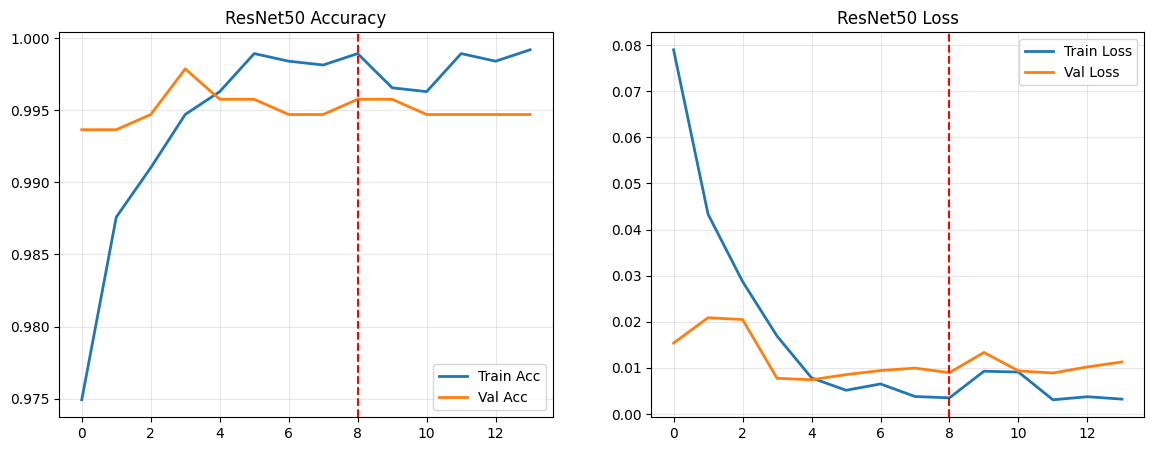

In [10]:
# ==========================
# VISUALIZATION
# ==========================
def plot_results(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Acc', lw=2)
    plt.plot(val_acc, label='Val Acc', lw=2)
    plt.axvline(x=len(h1.history['accuracy'])-1, color='r', ls='--')
    plt.title('ResNet50 Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss', lw=2)
    plt.plot(val_loss, label='Val Loss', lw=2)
    plt.axvline(x=len(h1.history['loss'])-1, color='r', ls='--')
    plt.title('ResNet50 Loss'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

plot_results(history, history_fine)

In [11]:
# ==========================
# SUBMISSION
# ==========================
print("\nGenerating submission...")
def load_and_prep(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img

files = sorted([f for f in os.listdir(TEST_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
image_paths = [os.path.join(TEST_DIR, f) for f in files]
test_ds = tf.data.Dataset.from_tensor_slices(image_paths).map(load_and_prep).batch(BATCH_SIZE)

probs = model.predict(test_ds).flatten()
preds = (probs >= 0.5).astype(int)
pred_labels = [class_names[p] for p in preds]

submission = pd.DataFrame({'ID': files, 'Label': pred_labels}).to_csv("submission.csv", index=False)
print("Submission saved!")


Generating submission...
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step
Submission saved!


In [16]:
submission = pd.DataFrame({'ID': files, 'Label': pred_labels})

In [17]:
submission.head(20)

,ID,Label
0,img_0_0.jpg,muffin
1,img_0_10.jpg,muffin
2,img_0_1000.jpg,muffin
3,img_0_1037.jpg,muffin
4,img_0_105.jpg,muffin
5,img_0_1050.jpg,muffin
6,img_0_1051.jpg,muffin
7,img_0_1061.jpg,muffin
8,img_0_1063.jpg,muffin
9,img_0_1071.jpg,chihuahua
